# Exploratory Data Analysis

## Satellite Risk Prediction Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('../data/processed/merged_catalog.parquet')

# Configure visual style
sns.set_theme(style='whitegrid')

## 1. Distribution Plots by Orbital Band

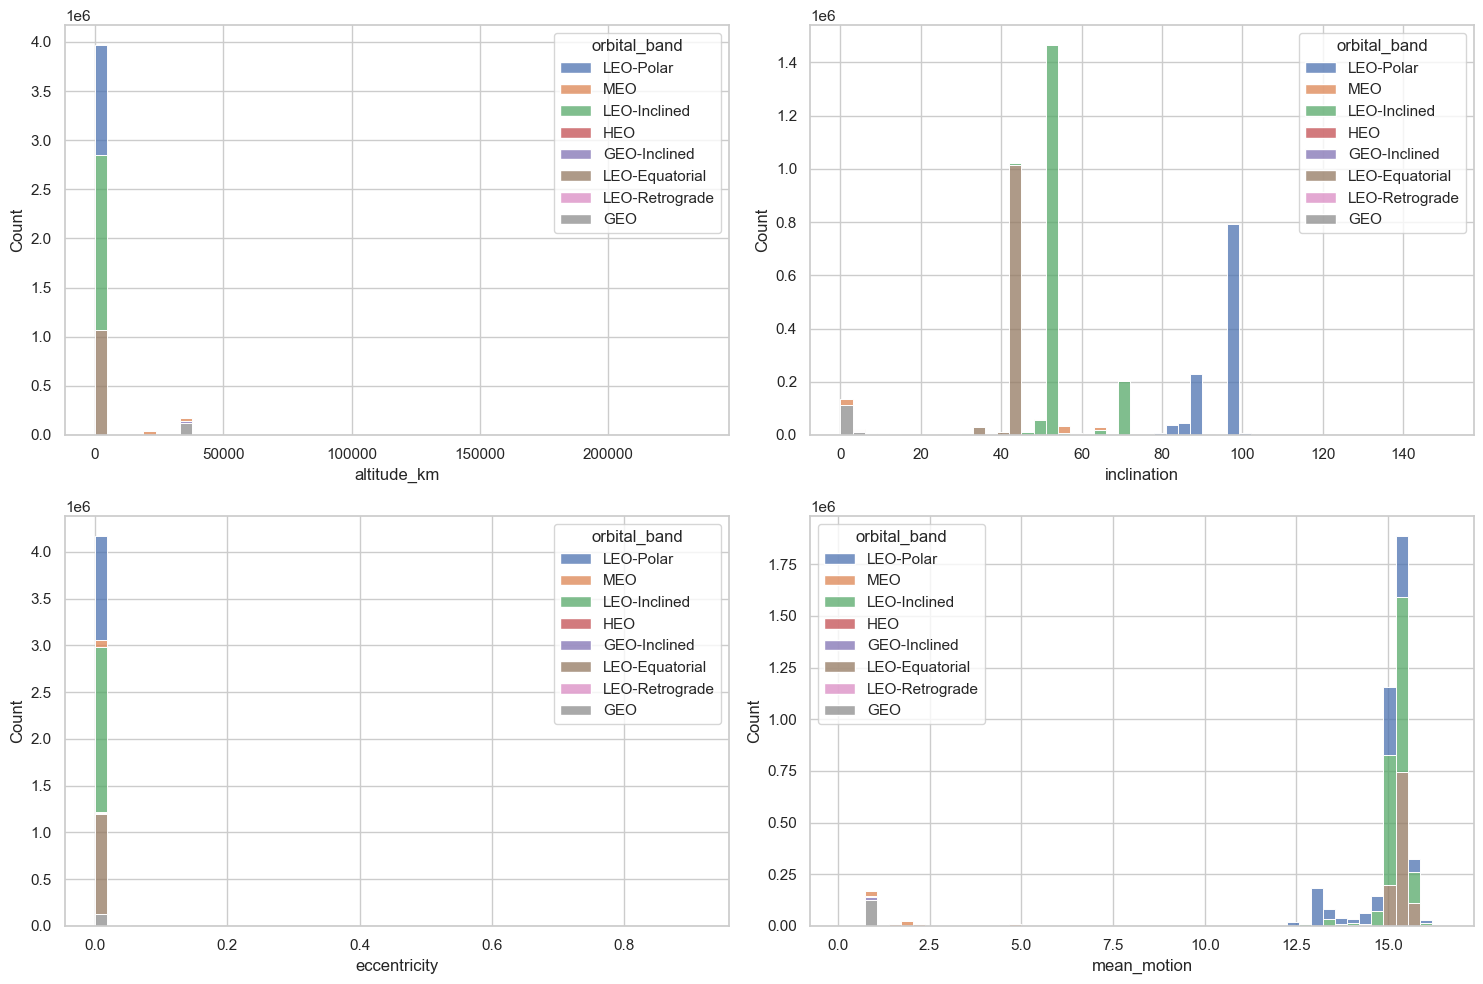

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(data=df, x='altitude_km', hue='orbital_band', bins=50, ax=axes[0,0], multiple='stack')
sns.histplot(data=df, x='inclination', hue='orbital_band', bins=50, ax=axes[0,1], multiple='stack')
sns.histplot(data=df, x='eccentricity', hue='orbital_band', bins=50, ax=axes[1,0], multiple='stack')
sns.histplot(data=df, x='mean_motion', hue='orbital_band', bins=50, ax=axes[1,1], multiple='stack')
plt.tight_layout()
plt.show()

## 2. Value Counts

In [3]:
print('--- Object Type ---')
print(df['object_type'].value_counts())

print('\n--- Orbit Lifetime Category ---')
print(df['orbit_lifetime_category'].value_counts())

print('\n--- Top 15 Satellite Constellations ---')
print(df['satellite_constellation'].value_counts().head(15))

print('\n--- Top 15 Countries ---')
print(df['country'].value_counts().head(15))

--- Object Type ---
object_type
PAYLOAD        4043474
UNKNOWN         152705
unknown           1955
ROCKET BODY       1779
DEBRIS               1
Name: count, dtype: int64

--- Orbit Lifetime Category ---
orbit_lifetime_category
<1yr       4199282
UNKNOWN        632
Name: count, dtype: int64

--- Top 15 Satellite Constellations ---
satellite_constellation
Starlink Gen 1    2816622
Other             1166409
OneWeb             184233
Beidou              15632
Galileo              9094
Glonass              7924
Name: count, dtype: int64

--- Top 15 Countries ---


country
US      3149496
PRC      365316
UK       196894
TBD       74136
CIS       73868
JPN       30798
IND       19705
FR        19473
IT        19059
ESA       18396
SKOR      15558
GER       14831
CA        14371
SES       13151
SPN       11833
Name: count, dtype: int64


## 3. Null Values Summary

In [4]:
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print('\nTotal missing values in processed dataset: ', nulls.sum())

Series([], dtype: int64)

Total missing values in processed dataset:  0


## 4. Trajectory Signal Analysis

Date range: 2025-11-04 00:00:00 to 2026-08-15 00:00:00



Snapshots per norad_id:
count    17073.000000
mean       245.997423
std         73.855067
min          1.000000
25%        262.000000
50%        283.000000
75%        283.000000
max        283.000000
dtype: float64


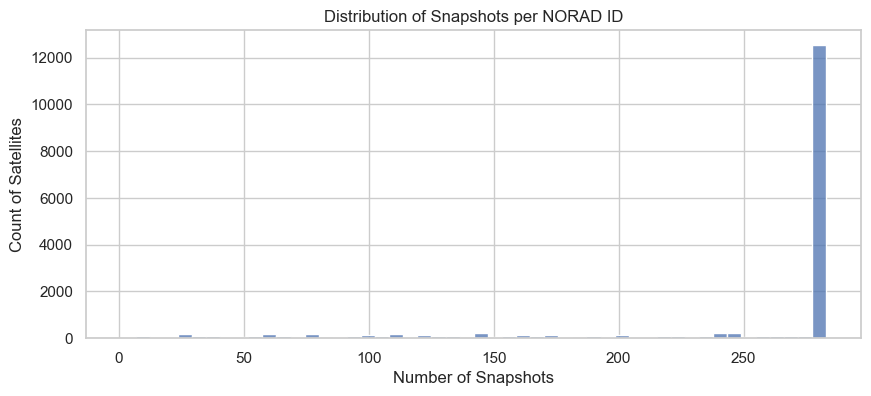

In [5]:
print(f'Date range: {df["snapshot_date"].min()} to {df["snapshot_date"].max()}')
snapshots_per_id = df.groupby('norad_id').size()
print('\nSnapshots per norad_id:')
print(snapshots_per_id.describe())

plt.figure(figsize=(10, 4))
sns.histplot(snapshots_per_id, bins=50)
plt.title('Distribution of Snapshots per NORAD ID')
plt.xlabel('Number of Snapshots')
plt.ylabel('Count of Satellites')
plt.show()

## 5. Observations

Based on the analysis:
1. The vast majority of tracked objects are classified as payloads (over 4 million records in the time series), with the Starlink Gen 1 constellation dominating the dataset by a huge margin.
2. Most objects in this dataset have an orbital lifetime category of <1yr, which heavily skews the distribution.
3. The trajectory data provides a very strong signal for velocity features, with a median of 283 snapshots per `norad_id` covering the period from November 2025 to August 2026.
4. Geopolitically, the US is the dominant owner/operator in the catalog, distantly followed by the PRC and the UK.
5. The data cleaning strategy successfully handled all missing values, resulting in zero nulls in the processed dataset.